In [7]:
from pathlib import Path

In [13]:
from pathlib import Path


DATA_DIR = Path("../raw-img")

print(DATA_DIR.exists())
print(DATA_DIR.resolve())

True
C:\Users\David Danell\PyTorch\PyTorch\CNN_pracice\raw-img


In [9]:
for item in DATA_DIR.iterdir():
    if item.is_dir():
        print(item.name)

cane
cavallo
elefante
farfalla
gallina
gatto
mucca
pecora
ragno
scoiattolo


In [10]:
from torchvision import datasets

dataset = datasets.ImageFolder(root=DATA_DIR)

print("Antal bilder:", len(dataset))
print("Klasser:", dataset.classes)
print("Class to index:", dataset.class_to_idx)

Antal bilder: 26179
Klasser: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Class to index: {'cane': 0, 'cavallo': 1, 'elefante': 2, 'farfalla': 3, 'gallina': 4, 'gatto': 5, 'mucca': 6, 'pecora': 7, 'ragno': 8, 'scoiattolo': 9}


In [11]:
from collections import Counter

labels= []

for path, label in dataset.samples:
    labels.append(label)

class_counts= Counter(labels)

for class_name, class_index in dataset.class_to_idx.items():
    count = class_counts[class_index]
    print(class_name, ":", count)

#print(class_counts)

cane : 4863
cavallo : 2623
elefante : 1446
farfalla : 2112
gallina : 3098
gatto : 1668
mucca : 1866
pecora : 1820
ragno : 4821
scoiattolo : 1862


EDA PÅ BILD

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

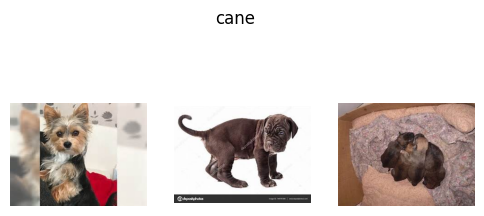

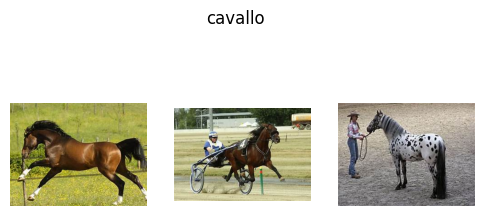

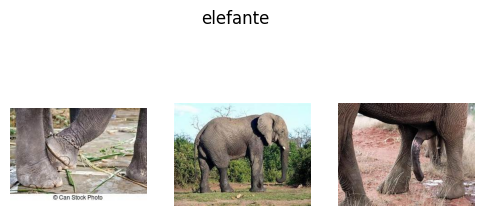

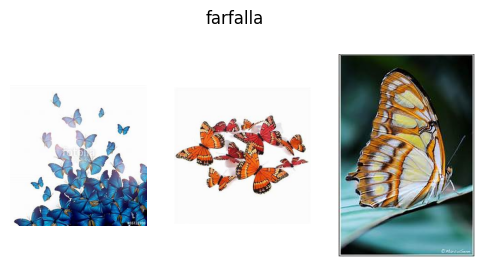

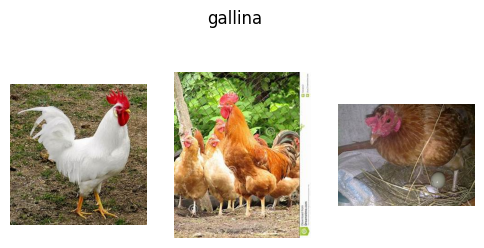

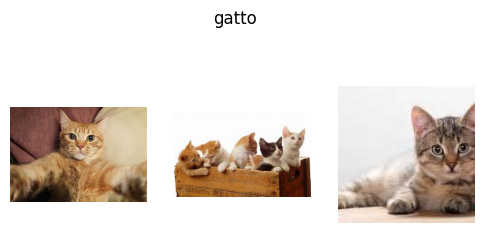

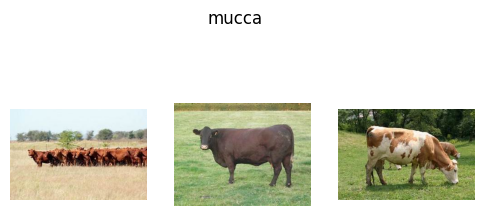

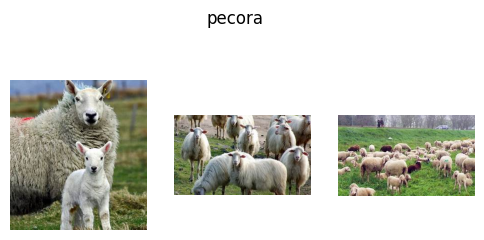

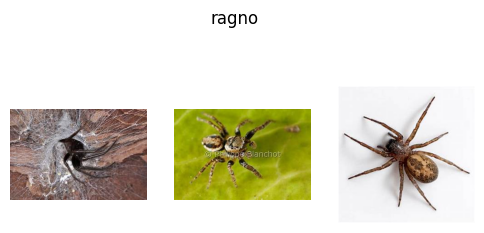

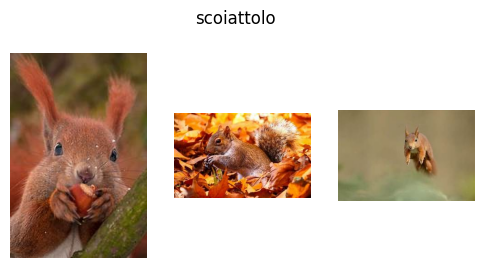

In [16]:
samples_per_class = 3

for class_name, class_index in dataset.class_to_idx.items():
    shown = 0

    plt.figure(figsize=(6, 3))
    plt.suptitle(class_name)

    for image_path, label in dataset.samples:
        if label == class_index:
            image = Image.open(image_path).convert("RGB")

            plt.subplot(1, samples_per_class, shown + 1)
            plt.imshow(image)
            plt.axis("off")

            shown += 1

            if shown == samples_per_class:
                break

    plt.show()

In [18]:
from PIL import Image
from collections import Counter

image_sizes = []

for image_path, label in dataset.samples:
    with Image.open(image_path) as image:
        image_sizes.append(image.size)  # (width, height)

size_counts = Counter(image_sizes)

print("Antal bilder:", len(image_sizes))
print("Antal unika bildstorlekar:", len(size_counts))

print("\n10 vanligaste storlekarna:")
for size, count in size_counts.most_common(10):
    print(size, ":", count)

Antal bilder: 26179
Antal unika bildstorlekar: 1002

10 vanligaste storlekarna:
(300, 225) : 4397
(300, 200) : 3281
(300, 300) : 1192
(300, 169) : 1048
(640, 426) : 694
(300, 199) : 586
(225, 300) : 490
(300, 240) : 403
(300, 188) : 393
(200, 300) : 362


In [19]:
smallest_image = min(image_sizes, key=lambda size: size[0] * size[1])
largest_image = max(image_sizes, key=lambda size: size[0] * size[1])

print("Minsta bildstorlek:", smallest_image)
print("Största bildstorlek:", largest_image)

Minsta bildstorlek: (60, 57)
Största bildstorlek: (6720, 4480)


In [20]:
small_images = []

for image_path, label in dataset.samples:
    with Image.open(image_path) as image:
        width, height = image.size

        if width < 100 or height < 100:
            small_images.append((image_path, image.size, label))

print("Antal bilder där bredd eller höjd är under 100 px:", len(small_images))

Antal bilder där bredd eller höjd är under 100 px: 23


In [22]:
from PIL import Image

bad_images = []

for image_path, label in dataset.samples:
    try:
        with Image.open(image_path) as image:
            image.verify()

        with Image.open(image_path) as image:
            image.convert("RGB")

    except Exception as error:
        bad_images.append((image_path, error))

print("Antal problematiska bilder:", len(bad_images))

Antal problematiska bilder: 0


In [23]:
file_extensions= []


for image_path, label in dataset.samples:
    extension = image_path.lower().split('.')[-1]
    file_extensions.append(extension)

extension_counts = Counter(file_extensions)

for extension, count in extension_counts.items():
    print(extension, ":", count)

jpeg : 24209
jpg : 1919
png : 51
